In [125]:
from langgraph.graph import StateGraph, START, END

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document

from dotenv import load_dotenv
from typing import TypedDict, Annotated, Literal, List
from pydantic import BaseModel, Field

In [126]:
load_dotenv()

True

In [127]:
docs = (
    PyPDFLoader(r"C:\Users\Administrator\Desktop\LangGraph Exploration\Day26_Self_RAG\documents\Company_Policies.pdf").load() +
    PyPDFLoader(r"C:\Users\Administrator\Desktop\LangGraph Exploration\Day26_Self_RAG\documents\Company_Profile.pdf").load() +
    PyPDFLoader(r"C:\Users\Administrator\Desktop\LangGraph Exploration\Day26_Self_RAG\documents\Product_and_Pricing.pdf").load()
)

In [128]:
splitter = RecursiveCharacterTextSplitter(chunk_size = 600, chunk_overlap = 150)
chunks = splitter.split_documents(docs)

In [129]:
embeddings = OpenAIEmbeddings(model = "text-embedding-3-small")
vector_store = FAISS.from_documents(chunks, embedding = embeddings)

In [130]:
retriever = vector_store.as_retriever(search_type = "similarity", search_kwargs = {"k": 4})

In [131]:
llm = ChatOpenAI(model = "gpt-4o-mini", temperature = 0)

In [132]:
class State(TypedDict):
    question: str
    needs_retrieval: bool
    docs: List[Document]
    relevant_docs: List[Document]
    context: str
    answer: str

    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str]

    # new
    retries: int

In [133]:
# same as before

class RetrievedDecision(BaseModel):
    should_retrieve: Annotated[bool, Field(description = "True if external documents are needed to answer reliably, else False.")]

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}")
    ]
)

should_retrieve_chain = decide_retrieval_prompt | llm.with_structured_output(RetrievedDecision)

def decide_retrieval(state: State):
    question = state['question']
    decision: RetrievedDecision = should_retrieve_chain.invoke({"question": question})
    return {"needs_retrieval": decision.should_retrieve}

In [134]:
# same as before

direct_generate_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}")
    ]
)

def generate_direct(state: State):
    out = llm.invoke(direct_generate_prompt.format_messages(question = state['question']))
    return {"answer": out.content}

In [135]:
# same as before

def retrieve(state: State):
    docs = retriever.invoke(state['question'])
    return {"docs": docs}

In [136]:
# same as before

def route_after_decide(state: State):
    if state['needs_retrieval']:
        return "retrieve"
    else:
        return "generate_direct"

In [137]:
# same as before

class RelevanceDecision(BaseModel):
    is_relevant: Annotated[bool, Field(description = "True if the document helps answer the question, else False.")]

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)

fetch_relevant_chain = is_relevant_prompt | llm.with_structured_output(RelevanceDecision)

def is_relevant(state: State):
    relevant_docs: List[Document] = []

    for doc in state['docs']:
        decision: RelevanceDecision = fetch_relevant_chain.invoke({"question": state['question'], "document": doc.page_content})
        if decision.is_relevant:
            relevant_docs.append(doc)
    
    return {"relevant_docs": relevant_docs}

In [138]:
# same as before

rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG assistant.\n"
            "Answer the user's question using ONLY the provided context.\n"
            "If the context does not contain enough information, say:\n"
            "'No relevant document found.'\n"
            "Do not use outside knowledge.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

def generate_from_context(state: State):
    context = "\n\n---\n\n".join(doc.page_content for doc in state.get("relevant_docs", [])).strip()
    if not context:
        return {"answer": "No relevant documents found", "context": ""}
    
    out = llm.invoke(rag_generation_prompt.format_messages(question = state['question'], context = context))
    return {"answer": out.content, "context": context}

In [139]:
# same as before

def no_relevant_docs(state: State):
    return {"answer": "No relevant documents found", "context": ""}

In [140]:
# same as before

def route_after_relevance(state: State):
    if state.get("relevant_docs") and len(state['relevant_docs']) > 0:
        return "generate_from_context"
    else:
        return "no_relevant_docs"

In [141]:
# same as before

class IsSUPDecision(BaseModel):
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: Annotated[
        List[str], 
        Field(
            default_factory = list, 
            description = "include up to 3 short direct quotes from CONTEXT that support the supported parts."
            )
        ]    # Again, this is just for debugging purpose. You can exclude it if you want.


issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
            "- Do not use outside knowledge."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

issup_chain = issup_prompt | llm.with_structured_output(IsSUPDecision)

def is_sup(state: State):
    decision: IsSUPDecision = issup_chain.invoke({
        "question": state['question'],
        "answer": state['answer'],
        "context": state['context']
    })

    return {"issup": decision.issup, "evidence": decision.evidence}

In [142]:
# new

revise_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
    ]
)

def revise_answer(state: State):
    out = llm.invoke(
        revise_prompt.format_messages(
            question = state['question'],
            answer = state['answer'],
            context = state['context']
        )
    )

    retries = state.get("retries", 0)
    retries += 1

    return {"answer": out.content, "retries": retries}

In [143]:
# new

def accept_answer(state: State):
    return {}  # keep the answer as-is

In [144]:
# new

MAX_RETRIES = 10

def route_after_issup(state: State):
    if state.get("issup") == "fully_supported":
        return "accept_answer"
    if state.get("retries", 0) >= MAX_RETRIES:
        return "accept_answer"   # or return a "give_up" node if you want
    return "revise_answer"

In [145]:
graph = StateGraph(State)

graph.add_node("decide_retrieval", decide_retrieval)
graph.add_node("generate_direct", generate_direct)
graph.add_node("retrieve", retrieve)
graph.add_node("is_relevant", is_relevant)
graph.add_node("generate_from_context", generate_from_context)
graph.add_node("no_relevant_docs", no_relevant_docs)
graph.add_node("is_sup", is_sup)
graph.add_node("revise_answer", revise_answer)  # new
graph.add_node("accept_answer", accept_answer)  # new

graph.add_edge(START, "decide_retrieval")
graph.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "retrieve": "retrieve",
        "generate_direct": "generate_direct"
    }
)
graph.add_edge("generate_direct", END)
graph.add_edge("retrieve", "is_relevant")

graph.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {
        "generate_from_context": "generate_from_context",
        "no_relevant_docs": "no_relevant_docs"
    }
)

graph.add_edge("no_relevant_docs", END)
graph.add_edge("generate_from_context", "is_sup")

# new edges
graph.add_conditional_edges(
    "is_sup",
    route_after_issup,
    {
        "accept_answer": "accept_answer",
        "revise_answer": "revise_answer"
    }
)

graph.add_edge("revise_answer", "is_sup")
graph.add_edge("accept_answer", END)

workflow = graph.compile()

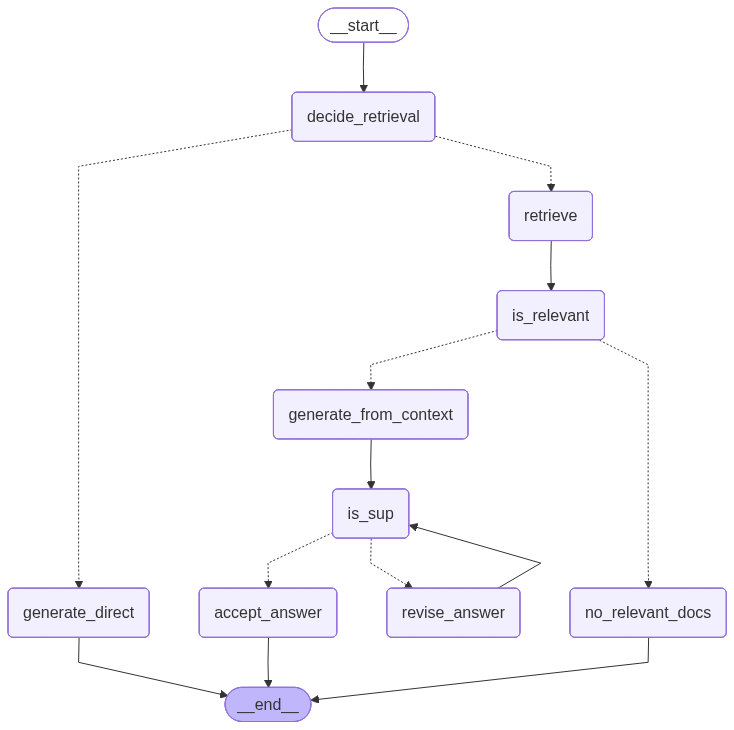

In [146]:
workflow

In [150]:
result = workflow.invoke(
    {
        "question": "Describe NexaAI’s company culture.",
        "docs": [],
        "relevant_docs": [],
        "context": "",
        "answer": "",
        "issup": "",
        "evidence": [],
        "retries": 0,
    },
    config={"recursion_limit": 80}  # recursion_limit = 80 means that the graph can execute at most 80 node transitions during this invocation so that infinite loop due to some reason is prevented.
)



print("needs_retrieval:", result.get("needs_retrieval"))
print("#docs:", len(result.get("docs", [])))
print("#relevant_docs:", len(result.get("relevant_docs", [])))
print("issup:", result.get("issup"))
print("evidence:", result.get("evidence"))
print("answer:", result.get("answer"))

needs_retrieval: True
#docs: 4
#relevant_docs: 1
issup: fully_supported
evidence: ['NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.', 'Employees are encouraged to maintain a healthy work-life balance.']
answer: - "NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace."
- "Employees are encouraged to maintain a healthy work-life balance."


In [151]:
result.get("retries", 0)

1